# IRKGL16 vs explicit symplectic integrators (Schwarzschild-black-hole)

Running the code cells below will compute and automatically generate the following figures:


- **From Section 5.3.1**

    - **Figure 4**, saved as **`Fig9.pdf`**

- **From Section 5.3.2**

    - **Figure 5(a)**, saved as **`Fig10.pdf`**
    - **Figure 5(b)**, saved as **`Fig11.pdf`**
  

<ul id="top">
    <li><a href="#Loading-packages-and-functions">Loading packages and functions</a></li>
    <li><a href="#Initial-value-problem:-Schwarzschild-black-hole">Initial-value-problem:-Schwarzschild-black-hole</a></li> 
    <li><a href="#IRKGL16-integrations">IRKGL16 integrations</a></li>
    <li><a href="#Splitting-integrations">Splitting integrations</a></li>
    <li><a href="#Benchmarks-diagrams">Benchmarks diagrams</a></li>
    <ul>
        <li><a href="#Work-precison-diagrams">Work-precison diagrams</a></li>
        <li><a href="#Select-integration-with-same-CPU-time">Select integration with same CPU time</a></li>
        <li><a href="#Error-in-Energy">Error in Energy</a></li>
        <li><a href="#Error-in-Solution">Error in Solution</a></li>
    </ul>
</ul>

## Loading packages and functions

In [1]:
using LinearAlgebra
using Plots
using LaTeXStrings
using BenchmarkTools
using IRKGaussLegendre

PATH_Splitting="../../"
include(string(PATH_Splitting,"/src/SplittingMethods.jl"))
using .SplittingMethods  

Base.@boundscheck false
pkgversion(IRKGaussLegendre) # must be v"0.2.13" or greater

v"0.2.13"

### Utils

In [2]:
mutable struct tsolutions_IRKGL16
    dts
    sols
    retcodes
    iters
    cpus
    fcns
    MaxΔHglobal
    MaxΔHlocal
    wcpu
    cpu_idx
end

function run_many_IRKGL16(alg, prob, ddt0, HAM; wcpu=true)

    u0=prob.u0
    parms=prob.p
    
    u0_B=BigFloat.(u0)
    parms_B=BigFloat.(parms)
    
    cpus=zero(ddt0)
    fcns=zero(ddt0)
    iters=zero(ddt0)
    retcodes=[true for k in ddt0]
    MaxΔHglobal=[0. for i in ddt0]
    MaxΔHlocal=[0. for i in ddt0]
    
    sols=Array{IRKGaussLegendre.ODESolution}(undef,length(ddt0))
    H0=HAM(u0_B,parms_B)
    
    for i in 1:length(ddt0)
        
        print(",",ddt0[i])    
        dt0=ddt0[i]
        
        sols[i]=solve(prob,alg,dt=dt0, adaptive=false)
        if sols[i].retcode==ReturnCode.Success
           iters[i]=sols[i].stats.nfpiter
           fcns[i]=iters[i]*8
        else
           retcodes[i]=false
           iters[i]=Inf
           fcns[i]=Inf
        end

        H = [HAM(BigFloat.(u),parms_B) for u in sols[i].u]
        ΔH0 = @. Float64(abs(H/H0-1))
        H_lerr = @. Float64(abs((H[2:end] / H[1:end-1]) - 1))
        MaxΔHglobal[i]=maximum(ΔH0)
        MaxΔHlocal[i]=maximum(H_lerr)

        if wcpu
            solve(prob,alg, dt=dt0, adaptive=false, save_everystep = false)
            cpus[i]= @belapsed solve($prob,$alg, dt=$dt0, adaptive=false, save_everystep = false)
        end
        
    end

    println("")
    return tsolutions_IRKGL16(ddt0, sols,retcodes,iters,cpus,fcns,MaxΔHglobal,MaxΔHlocal,wcpu,-1)

end  

run_many_IRKGL16 (generic function with 1 method)

In [3]:
mutable struct tsolutions_Splitting
   s
   r
   alg
   dts
   sols
   retcodes
  # nflowsH3
   cpus
   fcns 
   MaxΔHglobal
   MaxΔHlocal
   wcpu 
   cpu_idx
end

function run_many_Splitting(s, r, alg, prob, ddt0, HAM; wcpu=true)
    
    u0=prob.u0
    parms=prob.p
    
    u0_B=BigFloat.(u0)
    parms_B=BigFloat.(parms)
    
    cpus=zero(ddt0)
    fcns=zero(ddt0)
    #nflowsH3=similar(ddt0)
    retcodes=[true for k in ddt0]
    MaxΔHglobal=[0. for i in ddt0]
    MaxΔHlocal=[0. for i in ddt0]

    sols=Array{SplittingMethods.ODESolution}(undef,length(ddt0))
    H0=HAM(u0_B, parms_B)

    for i in 1:length(ddt0)

        print(",",ddt0[i])
        dt0=ddt0[i]  

        # save_everystep=true
        m0=1
        sols[i]=solver_Splitting(prob, alg, dt=dt0)

        if sols[i].success
           fcns[i]=sols[i].stats.naccept*s 
        else
           retcodes[i]=false
           fcns[i]=Inf
        end

        H = [HAM(BigFloat.(u),parms_B) for u in sols[i].u]
        ΔH0 = @. Float64(abs(H/H0-1))
        H_lerr = @. Float64(abs((H[2:end] / H[1:end-1]) - 1))
        MaxΔHglobal[i]=maximum(ΔH0)
        MaxΔHlocal[i]=maximum(H_lerr)

        if wcpu
            solver_Splitting(prob, alg, dt=dt0, save_everystep=false)
            cpus[i]=@belapsed solver_Splitting($prob, $alg, dt=$dt0, save_everystep=false)
        end
    end

    println("")
    return tsolutions_Splitting(s, r, alg, ddt0, sols,retcodes,cpus,fcns, MaxΔHglobal,MaxΔHlocal,wcpu,-1)
 
end

run_many_Splitting (generic function with 1 method)

In [4]:
function find_index_ge_cpu(lookup_value, v)

   idx=0
   for k in length(v):-1:1

       if v[k]>=lookup_value
          idx=k
          break
       end

   end

   return idx

end

function compute_index_ge_cpu!(indexes, lookup_value, manysols)

   for i  in 1:length(manysols)

      if manysols[i].wcpu  
         idx=find_index_ge_cpu(lookup_value, manysols[i].cpus)
         push!(indexes,idx)
      else
         push!(indexes,-1)
      end
   end

   return nothing

end

function lcm_floats_vector(numbers::Vector{Float64})
   # Convert the numbers to rationals
   rationals = rationalize.(numbers)
   # Compute the LCM iteratively
   lcm_rationals = reduce(lcm, rationals)
   return lcm_rationals
end

lcm_floats_vector (generic function with 1 method)

##### <a href="#top">Back to the top</a>

## Initial value problem: Schwarzschild black-hole

### Polar Coordinates (for IRKGL16)

In [5]:
""" 
Hamiltonian for Schwarzschild problem
(polar coordinates)  
"""
function Ham_Schwarzschild(u,parms)
     
   E=parms[1]
   L=parms[2]
   β=parms[3]
   r=u[1]
   θ=u[2]
   pr=u[3]
   pθ=u[4]

   E2=E*E
   r2=r*r
   pr2=pr*pr
   pθ2=pθ*pθ
   sinθ=sin(θ)
   sinθ2=sinθ*sinθ
   invsinθ2=1/sinθ2
   invr=1/r
   invr2=invr*invr


   H1=1/2*invr2*invsinθ2*(L-β/2*r2*sinθ2)^2-1/2*(r/(r-2))*E2
   H2= 1/2*(pr2+pθ2*invr2)
   H3= -invr*pr2

   return H1+H2+H3

end

""" 
ODE for Schwarzschild problem
(polar coordinates)  
"""
function SchwarzschildODE!(F,u,parms,t)

   E=parms[1]
   L=parms[2]
   β=parms[3]
   r=u[1]
   θ=u[2]
   pr=u[3]
   pθ=u[4]

   E2=E*E
   L2=L*L
   β2=β*β

   r2=r*r
   pr2=pr*pr
   pθ2=pθ*pθ
   invr=1/r
   invr2=invr*invr
   invr3=invr2*invr
   # sinθ, cosθ = sincos(θ) # no exist at SIMD
   sinθ=sin(θ)
   cosθ=cos(θ)
   sinθ2=sinθ*sinθ
   invsinθ=1/sinθ
   invsinθ2=invsinθ*invsinθ
   invsinθ3=invsinθ2*invsinθ
   sinθcosθ=sinθ*cosθ


   F[1]=(1-2*invr)*pr
   F[2]=pθ*invr2
   F[3]=-1/4*β2*r*sinθ2-(r/(r-2))^2*invr2*E2+L2*invsinθ2*invr3-pr2*invr2+pθ2*invr3
   F[4]=L2*cosθ*invsinθ3*invr2-1/4*β2*r2*sinθcosθ

   return nothing

end


""" 
Initial values for Schwarzschild problem
(polar coordinates)  
"""
function InitialSchwarzschild(T = Float64)
    
    parms = BigFloat[0.995,4.6,8.9e-5]

    r = 11
    θ =  pi/2
    pr = 0
    u0 = BigFloat[r, θ, pr, 0]

    pθ = r * sqrt(-1 -2*Ham_Schwarzschild(u0,parms))

    parms = convert.(T, parms)
 
    u0 = convert.(T, [r, θ, pr, pθ])

    return u0, parms

end

InitialSchwarzschild

In [6]:
u0, parms = InitialSchwarzschild()

t0=0.
tF=1e5  #1e4
tspan=(t0,tF)

prob = ODEProblem{true,SciMLBase.FullSpecialize}(SchwarzschildODE!, u0, tspan , parms)

HAM=Ham_Schwarzschild
@show(HAM(u0,parms));

HAM(u0, parms) = -0.5


### Cartesian coordinates (for explicit splitting methods)

In [7]:
""" 
Hamiltonian for Schwarzschild problem
(cartesian coordinates)  
"""
function Ham_Schwarzschildv2(u,parms)
     
   E=parms[1]
   L=parms[2]
   β=parms[3]
   x=u[1]
   y=u[2]
   px=u[3]
   py=u[4]


   H1= H1v2(u,parms)
   H2= H2v2(u,parms)
   H3= H3v2(u,parms)

   return H1+H2+H3

end

function H1v2(u,parms)
     
   E=parms[1]
   L=parms[2]
   β=parms[3]
   x=u[1]
   y=u[2]
   px=u[3]
   py=u[4]

   x2=x*x
   y2=y*y
   r2=x2+y2
   E2=E*E
   r=sqrt(r2)
   
   w= L-β/2*y2

   H1=1/(2*y2)*w^2-1/2*(r/(r-2))*E2


   return H1

end

function H2v2(u,parms)
     
   E=parms[1]
   L=parms[2]
   β=parms[3]
   x=u[1]
   y=u[2]
   px=u[3]
   py=u[4]


   H2= 1/2*(px*px+py*py)

   return H2

end

function H3v2(u,parms)
     
   E=parms[1]
   L=parms[2]
   β=parms[3]
   x=u[1]
   y=u[2]
   px=u[3]
   py=u[4]
   
   x2=x*x
   y2=y*y
   r2=x2+y2
   r=sqrt(r2)
   
   c=x/r
   s=y/r
   

   H3= -(px*c+py*s)^2/r        

end

""" 
Initial values for Schwarzschild problem
(cartesian coordinates)  
"""
function InitialSchwarzschildv2(T = Float64)
    
    parms = BigFloat[0.995,4.6,8.9e-5]

    r = 11
    θ =  pi/2
    pr = 0

    u0 = BigFloat[r, θ, pr, 0]

    pθ = r * sqrt(-1 -2*Ham_Schwarzschild(u0,parms))
    parms = convert.(T, parms)
 
    c=cos(θ)
    s=sin(θ)
    x=r*c
    y=r*s
    px=c*pr-s*pθ/r
    py=s*pr+c*pθ/r
    u0 = convert.(T, [x, y, px, py])

    return u0, parms

end

""" 
Flow H1 (cartesian coordinates)  
"""
function flowH1Schwarzschildv2!(uj,ej,h,parms)


   E=parms[1]
   L=parms[2]
   β=parms[3]

   x=uj[1]
   y=uj[2]
   px=uj[3]
   py=uj[4]

   z = y*y
   r2= x*x+z
   r=sqrt(r2)
   w= L-β/2*z
   u= 1-2/r
   W= -w/z
   U= -E*E/(2*u*u)
   R= U/(r*r2)
   Z= R+(W-β)*W/2   

   gradpx=-2*x*R
   gradpy=-2*y*Z

   uj[3]=px-h*gradpx
   uj[4]=py-h*gradpy

   return nothing


end

""" 
Flow H2 (cartesian coordinates)  
"""
function flowH2Schwarzschildv2!(uj,ej,h,parms)

   x=uj[1]
   y=uj[2]
   px=uj[3]
   py=uj[4]

   
   uj[1]=x+h*px
   uj[2]=y+h*py

   return nothing

end

""" 
Flow H3 (cartesian coordinates)  
"""
function flowH3Schwarzschildv2!(uj,ej,h,parms)

   x=uj[1]
   y=uj[2]
   px=uj[3]
   py=uj[4]

   r2=x^2+y^2
   r=sqrt(r2)

   c=x/r
   s=y/r
   ptheta=-y*px+x*py
   nu= x*px+y*py
   mu=nu*nu/(r*r2)
   
   nu_=nu-3*h*mu
   pr_=cbrt(mu*nu_)
   r_=nu_/pr_
   
   uj[1]=r_*c
   uj[2]=r_*s
   ptr=ptheta/r_
   uj[3]=c*pr_-s*ptr
   uj[4]=s*pr_+c*ptr


   return nothing

end


flowH3Schwarzschildv2!

In [8]:
u0v2, parmsv2 = InitialSchwarzschildv2()
HAMV2=Ham_Schwarzschildv2

flows=[flowH1Schwarzschildv2!, flowH2Schwarzschildv2!, flowH3Schwarzschildv2!]
prob_split=SplittingProblem(flows, u0v2, tspan, parmsv2);

@show HAMV2(u0v2,parmsv2);

HAMV2(u0v2, parmsv2) = -0.5


<a href="#top">Back to the top</a>

## IRKGL16 integrations (s=8)


In [9]:
ddt0_irk16=collect(10.:2:30)

println("simd:")
alg=IRKGL16(simd=true, fseq=false)
sols_irk16_simd=run_many_IRKGL16(alg, prob, ddt0_irk16, HAM)
#
println("seq:")
alg=IRKGL16(simd=false, fseq=true)
sols_irk16_seq=run_many_IRKGL16(alg,prob,ddt0_irk16,HAM)
#
println("hybrid:")
alg=IRKGL16(simd=true, fseq=true)
sols_irk16_hyb=run_many_IRKGL16(alg,prob,ddt0_irk16,HAM);

simd:
,10.0,12.0,14.0,16.0,18.0,20.0,22.0,24.0,26.0,28.0,30.0
seq:
,10.0,12.0,14.0,16.0,18.0,20.0,22.0,24.0,26.0,28.0,30.0
hybrid:
,10.0,12.0,14.0,16.0,18.0,20.0,22.0,24.0,26.0,28.0,30.0


┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194


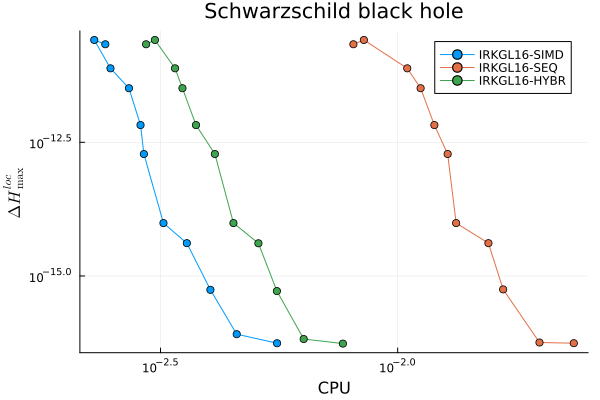

┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194


In [10]:
#
sols2plot=[sols_irk16_simd, sols_irk16_seq, sols_irk16_hyb]
labels2plot=["IRKGL16-SIMD", "IRKGL16-SEQ", "IRKGL16-HYBR"]

pl_=plot(title="Schwarzschild black hole", xlabel="CPU", ylabel=L"\Delta H^{loc}_{\mathrm{max}}",
          scale=:log10)

for i in 1:length(sols2plot)
    sols=sols2plot[i]
    plot!(pl_, sols.cpus , sols.MaxΔHlocal, markershape=:circle, label=labels2plot[i])
end
display(pl_)

<a href="#top">Back to the top</a>

## Splitting integrations

### Composition methods

In [11]:
#ddt0_split=collect(0.5:0.25:5)
ddt0_split=collect(0.5:0.25:3.5)

println("Strang: s=1")
s=1; r=2
alg=Splitting_alg(r=r, rkn=false)
sols_split_r2=run_many_Splitting(s, r, alg, prob_split, ddt0_split, HAMV2, wcpu=true)
#
println("SUZ90: s=5")
s=5; r=4
alg=Splitting_alg(r=r, rkn=false)
sols_split_r4=run_many_Splitting(s, r, alg, prob_split, s*ddt0_split, HAMV2, wcpu=true)
#
println("SS05: s=13")
s=13; r=6
alg=Splitting_alg(r=r, rkn=false)
sols_split_r6=run_many_Splitting(s, r, alg, prob_split, s*ddt0_split, HAMV2, wcpu=true)
#
println("SS05: s=21")
s=21; r=8
alg=Splitting_alg(r=r, rkn=false)
sols_split_r8=run_many_Splitting(s, r, alg, prob_split, s*ddt0_split, HAMV2, wcpu=true)
#
println("SS05: s=35")
s=35; r=10
alg=Splitting_alg(r=r, rkn=false)
sols_split_r10=run_many_Splitting(s, r, alg, prob_split, s*ddt0_split, HAMV2, wcpu=true);

Strang: s=1
,0.5,0.75,1.0,1.25,1.5,1.75,2.0,2.25,2.5,2.75,3.0,3.25,3.5
SUZ90: s=5
,2.5,3.75,5.0,6.25,7.5,8.75,10.0,11.25,12.5,13.75,15.0,16.25,17.5
SS05: s=13
,6.5,9.75,13.0,16.25,19.5,22.75,26.0,29.25,32.5,35.75,39.0,42.25,45.5
SS05: s=21
,10.5,15.75,21.0,26.25,31.5,36.75,42.0,47.25,52.5,57.75,63.0,68.25,73.5
SS05: s=35
,17.5,26.25,35.0,43.75,52.5,61.25,70.0,78.75,87.5,96.25,105.0,113.75,122.5


<a href="#top">Back to the top</a>

## Benchmarks diagrams


In [12]:
sols2plot=[sols_irk16_simd, sols_irk16_seq, sols_irk16_hyb,
           sols_split_r2, sols_split_r4, sols_split_r6, sols_split_r8, sols_split_r10]

labels2plot=["IRKGL16-SIMD", "IRKGL16-SEQ", "IRKGL16-HYBR", 
             "Strang(r=2)", "SUZ90(r=4)", "SS05(r=6)", "SS05(r=8)", "SS05(r=10)"] 

colors2plot=[:red, :blue, :green,
             :orange, :purple, :cyan, :magenta, :teal];

### Work-precison diagrams

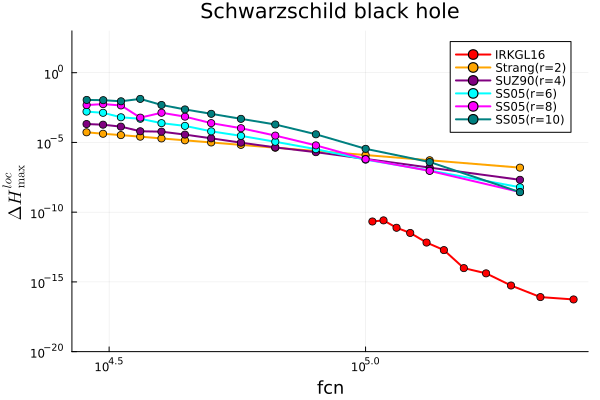

┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194


In [13]:
yrange=(1e-20, 1e3)
xrange=(1,50)

sols=sols2plot[1]

pl3=plot( title="Schwarzschild black hole", 
         xlabel="fcn", ylabel=L"\Delta H^{loc}_{\mathrm{max}}",
         guidefont=font(12), labelsize=10,
         scale=:log10, ylimits=yrange)

plot!(pl3,sols.fcns,sols.MaxΔHlocal, 
         markershape=:circle, lw=2,
         label="IRKGL16", color=colors2plot[1])

for i in 4:length(sols2plot)
       
   sols=sols2plot[i]
    
   plot!(pl3, sols.fcns , sols.MaxΔHlocal, 
         markershape=:circle, lw=2,
         label=labels2plot[i], color=colors2plot[i])
end

display(pl3)

### Select integration with same CPU-time 

#### SIMD

In [14]:
sols=sols2plot[1]
@show labels2plot[1]
[sols.MaxΔHlocal sols.cpus]

labels2plot[1] = "IRKGL16-SIMD"


11×2 Matrix{Float64}:
 5.5311e-17   0.00556843
 8.16308e-17  0.00457779
 5.51513e-16  0.00402896
 4.10706e-15  0.0035933
 9.75023e-15  0.0032077
 1.90708e-13  0.00291704
 6.63047e-13  0.00286981
 3.23864e-12  0.00271292
 7.62524e-12  0.00248028
 2.58407e-11  0.00229268
 2.148e-11    0.00241897

In [15]:
index0=4   # IRKGL16-SIMD: h=16, index0=4 (exact solution)
idx=5      # IRKGL16-SIMD: index1=5  MaxΔHlocal~ 10^{-14}

index=[idx]
compute_index_ge_cpu!(index, sols_irk16_simd.cpus[idx], sols2plot[2:end])

println("Checking CPU times")

for i in 1:length(index)
    
    k=index[i]
    if sols2plot[i].wcpu
       sols2plot[i].cpu_idx=k
       println(k, " , ", labels2plot[i], " , ", sols2plot[i].dts[k], " , ", sols2plot[i].cpus[k], " , ", sols2plot[i].MaxΔHlocal[k])
    end
    
end

Checking CPU times
5 , IRKGL16-SIMD , 18.0 , 0.003207705 , 9.75022684245944e-15
11 , IRKGL16-SEQ , 30.0 , 0.008065884 , 2.147997240978542e-11
9 , IRKGL16-HYBR , 26.0 , 0.003393464 , 7.625243275435525e-12
12 , Strang(r=2) , 3.25 , 0.003379097 , 4.201909211913646e-5
9 , SUZ90(r=4) , 12.5 , 0.003349961 , 5.9352499371604e-5
8 , SS05(r=6) , 29.25 , 0.003489254 , 0.00015380407445663238
8 , SS05(r=8) , 47.25 , 0.003566767 , 0.0007070091551386528
8 , SS05(r=10) , 78.75 , 0.003549295 , 0.0023242506864044987


#### Adjust step-size for splitting integrations


In [16]:
IRKGL16_cpu=sols2plot[1].cpus[idx]

0.003207705

##### Strangr2

In [17]:
idx_met=4
idx_dt=index[idx_met]
method=sols2plot[idx_met]
println([sols2plot[1].cpus[idx]  labels2plot[idx_met] method.dts[idx_dt] method.cpus[idx_dt] ])

if method.wcpu
    h1=method.dts[idx_dt]
    T1=method.cpus[idx_dt] 
    T2=IRKGL16_cpu
    @show h2=floor(h1*T1/T2)
    h2=3.25

    s=method.s; r=method.r
    println(labels2plot[idx_met],",r=",r,",s=",s)
    alg=Splitting_alg(r=r, rkn=false)
    strangr2=run_many_Splitting(s, r, alg, prob_split, [h2], HAMV2, wcpu=true)
    println([sols2plot[1].cpus[idx]  labels2plot[idx_met] strangr2.dts strangr2.cpus strangr2.MaxΔHlocal])
end

Any[0.003207705 "Strang(r=2)" 3.25 0.003379097]
h2 = floor((h1 * T1) / T2) = 3.0
Strang(r=2),r=2,s=1
,3.25
Any[0.003207705 "Strang(r=2)" 3.25 0.003353136 4.201909211913646e-5]


##### SUZ90r4

In [18]:
idx_met=5
idx_dt=index[idx_met]
method=sols2plot[idx_met]
println([sols2plot[1].cpus[idx]  labels2plot[idx_met] method.dts[idx_dt] method.cpus[idx_dt] ])

if method.wcpu
    h1=method.dts[idx_dt]
    T1=method.cpus[idx_dt] 
    T2=IRKGL16_cpu
    @show h2=floor(h1*T1/T2)
    h2=14.0

    s=method.s; r=method.r
    println(labels2plot[idx_met],",r=",r,",s=",s)
    alg=Splitting_alg(r=r, rkn=false)
    suz90r4=run_many_Splitting(s, r, alg, prob_split, [h2], HAMV2, wcpu=true)
    println([sols2plot[1].cpus[idx]  labels2plot[idx_met] suz90r4.dts suz90r4.cpus suz90r4.MaxΔHlocal])
end

Any[0.003207705 "SUZ90(r=4)" 12.5 0.003349961]
h2 = floor((h1 * T1) / T2) = 13.0
SUZ90(r=4),r=4,s=5
,14.0
Any[0.003207705 "SUZ90(r=4)" 14.0 0.002906245 0.00010266166030033799]


##### SS05r6

In [19]:
idx_met=6
idx_dt=index[idx_met]
method=sols2plot[idx_met]
println([sols2plot[1].cpus[idx]  labels2plot[idx_met] method.dts[idx_dt] method.cpus[idx_dt] ])

if method.wcpu
    h1=method.dts[idx_dt]
    T1=method.cpus[idx_dt] 
    T2=IRKGL16_cpu
    @show h2=floor(h1*T1/T2)

    s=method.s; r=method.r
    println(labels2plot[idx_met],",r=",r,",s=",s)
    alg=Splitting_alg(r=r, rkn=false)
    ss05r6=run_many_Splitting(s, r, alg, prob_split, [h2], HAMV2, wcpu=true)
    println([sols2plot[1].cpus[idx]  labels2plot[idx_met] ss05r6.dts ss05r6.cpus ss05r6.MaxΔHlocal])
end

Any[0.003207705 "SS05(r=6)" 29.25 0.003489254]
h2 = floor((h1 * T1) / T2) = 31.0
SS05(r=6),r=6,s=13
,31.0
Any[0.003207705 "SS05(r=6)" 31.0 0.003230015 0.00020049897623622474]


##### SS05r8

In [20]:
idx_met=7
idx_dt=index[idx_met]
method=sols2plot[idx_met]
println([sols2plot[1].cpus[idx]  labels2plot[idx_met] method.dts[idx_dt] method.cpus[idx_dt] ])

if method.wcpu
    h1=method.dts[idx_dt]
    T1=method.cpus[idx_dt] 
    T2=IRKGL16_cpu
    @show h2=floor(h1*T1/T2)

    s=method.s; r=method.r
    println(labels2plot[idx_met],",r=",r,",s=",s)
    alg=Splitting_alg(r=r, rkn=false)
    ss05r8=run_many_Splitting(s, r, alg, prob_split, [h2], HAMV2, wcpu=true)
    println([sols2plot[1].cpus[idx]  labels2plot[idx_met]  ss05r8.dts  ss05r8.cpus  ss05r8.MaxΔHlocal])
end

Any[0.003207705 "SS05(r=8)" 47.25 0.003566767]
h2 = floor((h1 * T1) / T2) = 52.0
SS05(r=8),r=8,s=21
,52.0
Any[0.003207705 "SS05(r=8)" 52.0 0.003150568 0.0009346652616396713]


##### SS05r10

In [21]:
idx_met=8
idx_dt=index[idx_met]
method=sols2plot[idx_met]
println([sols2plot[1].cpus[idx]  labels2plot[idx_met] method.dts[idx_dt] method.cpus[idx_dt] ])

if method.wcpu
    h1=method.dts[idx_dt]
    T1=method.cpus[idx_dt] 
    T2=IRKGL16_cpu
    @show h2=floor(h1*T1/T2)
    h2=100.0

     s=method.s; r=method.r
    println(labels2plot[idx_met],",r=",r,",s=",s)
    alg=Splitting_alg(r=r, rkn=false)
    ss05r10=run_many_Splitting(s,r, alg, prob_split, [h2], HAMV2, wcpu=true)
    println([sols2plot[1].cpus[idx]  labels2plot[idx_met]   ss05r10.dts   ss05r10.cpus   ss05r10.MaxΔHlocal])

end

Any[0.003207705 "SS05(r=10)" 78.75 0.003549295]
h2 = floor((h1 * T1) / T2) = 87.0
SS05(r=10),r=10,s=35
,100.0
Any[0.003207705 "SS05(r=10)" 100.0 0.002717648 0.009992696027359324]


##### Work-precisions (CPUS)

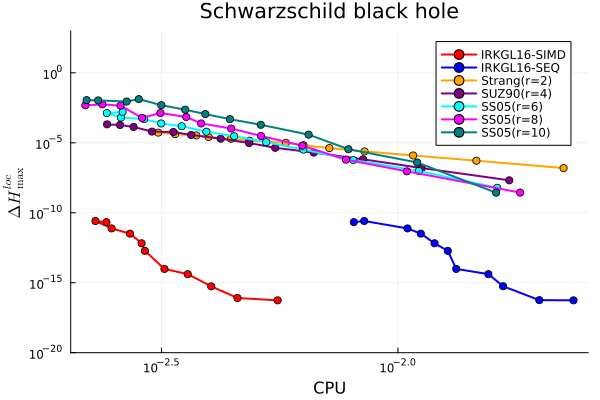

┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194


In [22]:

yrange=(1e-20, 1e3)

xrange=(1,50)

sols=sols_irk16_simd
pl1=plot( sols.cpus , sols.MaxΔHlocal, scale=:log10,
          markershape=:circle, lw=2,
          ylimits=yrange, 
          label=labels2plot[1], color=colors2plot[1],
          title="Schwarzschild black hole", xlabel="CPU", ylabel=L"\Delta H^{loc}_{\mathrm{max}}")

for i in 2:length(sols2plot)

    if i!=3  # except hybrid
        sols=sols2plot[i]
    
        if sols.wcpu
           plot!(pl1, sols.cpus , sols.MaxΔHlocal, 
                 markershape=:circle, lw=2,
                 label=labels2plot[i], color=colors2plot[i],
                 scale=:log10)
        end
    end
end

#vline!(pl1, [sols_irk16_simd.cpus[index[1]]], line=:dash, label="", color=:red)
#annotate!((sols_irk16_simd.cpus[index[1]]+0.12, 0.05), text("opt", :red, 10, :center))
plot(pl1)

In [23]:
savefig("./figures/Fig9.pdf")

┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194


"/home/mikel/Nextcloud/Gure taldea (Ehu box)/IRKGL-2025/6-Splitting-metodoak/Splitting Solvers Implementation/Experiments_Article_2026/5-3- Numerical comprarisons of IRKGL16 with explicit symplectic integrators/figures/Fig9.pdf"

#### Resume

In [24]:
# simd
i=1
idx=index[i] #sols2plot[i].cpu_idx
cpu=sols2plot[i].cpus[idx]
fcn=sols2plot[i].fcns[idx]
cpu_fcn_simd=cpu/fcn
# seq
i=2
idx=index[i] #sols2plot[i].cpu_idx
cpu=sols2plot[i].cpus[idx]
fcn=sols2plot[i].fcns[idx]
cpu_fcn_seq=cpu/fcn
# hybr
i=3
idx=index[i] #sols2plot[i].cpu_idx
cpu=sols2plot[i].cpus[idx]
fcn=sols2plot[i].fcns[idx]
cpu_fcn_hybr=cpu/fcn

#####################################

cpu=ss05r8.cpus[1]
fcn=ss05r8.fcns[1]
MaxΔHlocal=ss05r8.MaxΔHlocal[1]
cpu_fcn3=cpu_fcn_simd/(cpu/fcn)

cpu_fcn1=cpu_fcn_seq/(cpu/fcn)

cpu_fcn2=cpu_fcn_hybr/(cpu/fcn)



println("SS05(r=8)", ",seq=", cpu_fcn1, ",hybr=", cpu_fcn2, ",simd=", cpu_fcn3)
println("MaxΔHlocal", ",seq=", nothing, ",hybr=", nothing, ",simd=", MaxΔHlocal)


SS05(r=8),seq=1.002789606079986,hybr=0.37927023932058707,simd=0.2646470993733469
MaxΔHlocal,seq=nothing,hybr=nothing,simd=0.0009346652616396713


<a href="#top">Back to the top</a>

### Error in Energy

In [25]:

methods2plot=[sols_irk16_simd, strangr2, suz90r4, ss05r6, ss05r8, ss05r10]

labels2plot_=["IRKGL16-SIMD", 
              "Strang(r=2)", "SUZ90(r=4)", "SS05(r=6)", "SS05(r=8)", "SS05(r=10)" ]

colors2plot_ = [:red, # :blue, :green,
                :orange, :purple, :cyan, :magenta, :teal];


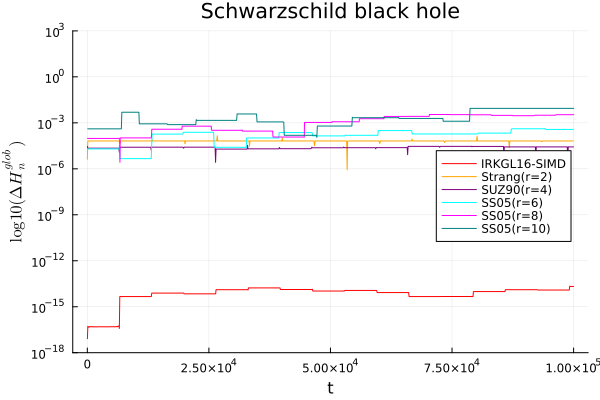

In [26]:
yrange=(1e-18, 1e3)

pl3=plot(title="Schwarzschild black hole",
         xlabel="t", ylabel=L"\log10(\Delta H^{glob}_n)",
         ylimits=yrange, yscale=:log10, legend=:right) #:topleft)

H0=HAM(BigFloat.(u0),BigFloat.(parms))
H = [HAM(BigFloat.(u),BigFloat.(parms)) for u in sols_irk16_simd.sols[index[1]].u]
ΔH0 = @. Float64(abs(H/H0-1))

m0 = max(1,div(Int64(ceil((tF-t0)/ddt0_irk16[index[1]])),1000))

plot!(pl3, sols_irk16_simd.sols[index[1]].t[2:m0:end], abs.(ΔH0[2:m0:end]),
           label=labels2plot_[1],color=colors2plot_[1])

# splitting


H0=HAMV2(BigFloat.(u0v2),BigFloat.(parmsv2))
for k in 2:length(methods2plot)
    
    if methods2plot[k].wcpu
        #idx=methods2plot[k].cpu_idx
        idx=1
        solk=methods2plot[k].sols[idx]
        dt_split=methods2plot[k].dts[idx]
        m0 = max(1,div(Int64(ceil((tF-t0)/ dt_split)),1000))
        labelk=labels2plot_[k]
        colork=colors2plot_[k]
        H = [HAMV2(BigFloat.(u),BigFloat.(parmsv2)) for u in solk.u]
        ΔH0 = @. Float64(abs(H/H0-1))
        plot!(pl3, solk.t[2:m0:end], abs.(ΔH0[2:m0:end]), yscale=:log10, label=labelk, color=colork)
    end
end

plot(pl3)



In [27]:
savefig("./figures/Fig10.pdf")

"/home/mikel/Nextcloud/Gure taldea (Ehu box)/IRKGL-2025/6-Splitting-metodoak/Splitting Solvers Implementation/Experiments_Article_2026/5-3- Numerical comprarisons of IRKGL16 with explicit symplectic integrators/figures/Fig10.pdf"

<a href="#top">Back to the top</a>

### Error in Solution

In [28]:
methods2plot=[sols_irk16_simd, strangr2, suz90r4, ss05r6, ss05r8, ss05r10]

labels2plot_er=["IRKGL16-SIMD",  
                "Strang(r=2)", "SUZ90(r=4)", "SS05(r=6)", "SS05(r=8)", "SS05(r=10)"] 

colors2plot_er  = [:red, #:blue, :green,
                   :orange, :purple, :cyan, :magenta, :teal];

k=1,IRKGL16-SIMD,[80.0, 160.0, 240.0]
k=1,IRKGL16-SIMD,[80.0, 160.0, 240.0]
*****************************
k=2,Strang(r=2),[208.0, 416.0, 624.0]
k=2,Strang(r=2),[208.0, 416.0, 624.0]
*****************************
k=3,SUZ90(r=4),[112.0, 224.0, 336.0]
k=3,SUZ90(r=4),[112.0, 224.0, 336.0]
*****************************
k=4,SS05(r=6),[496.0, 992.0, 1488.0]
k=4,SS05(r=6),[496.0, 992.0, 1488.0]
*****************************
k=5,SS05(r=8),[208.0, 416.0, 624.0]
k=5,SS05(r=8),[208.0, 416.0, 624.0]
*****************************
k=6,SS05(r=10),[400.0, 800.0, 1200.0]
k=6,SS05(r=10),[400.0, 800.0, 1200.0]
*****************************


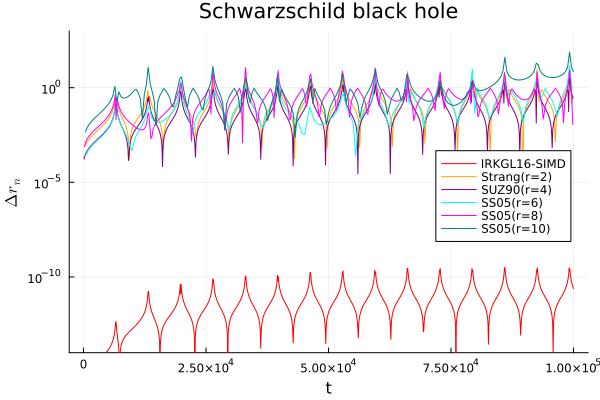

In [29]:
yrange=(1e-14, 1e3)

pe1=plot(title="Schwarzschild black hole", yscale=:log10,
         ylims=yrange,
         legend=:right, #:bottomright,
         xlabel="t", ylabel=L"\Delta r_n")

for k in 1:length(methods2plot)

    if methods2plot[k].wcpu

        #idx=methods2plot[k].cpu_idx
        idx=1
        errors2plot=methods2plot[k].sols[idx]
        ddt02plot=methods2plot[k].dts[idx]
        
        w=lcm_floats_vector(vcat(ddt0_irk16[index0],ddt02plot))
        ii=Int64.(w./(vcat(ddt0_irk16[index0],ddt02plot))).+1
        
        v0=sols_irk16_simd.sols[index0].t[ii[1]:ii[1]-1:3*ii[1]] 
        v1=errors2plot.t[ii[2]:ii[2]-1:3*ii[2]]
        
        println("k=", k, ",",labels2plot_er[k],",", v0 )
        println("k=", k, ",",labels2plot_er[k],",", v1 )
        println("*****************************")
        
        if k==1
            error= map((u,u1)-> abs(BigFloat(u[1])/BigFloat(u1[1])-1),
                    errors2plot.u[ii[2]:ii[2]-1:end], sols_irk16_simd.sols[index0].u[ii[1]:ii[1]-1:end])
        
        else
           # r=sqrt(x^2+y^2) for splitting methods
           error= map((u,u1)-> abs(sqrt(BigFloat(u[1])^2+BigFloat(u[2])^2)/BigFloat(u1[1])-1),
                    errors2plot.u[ii[2]:ii[2]-1:end], sols_irk16_simd.sols[index0].u[ii[1]:ii[1]-1:end])
        end 


        tt=sols_irk16_simd.sols[index0].t[ii[1]:ii[1]-1:end]
        
        plot!(pe1, tt, error,
              label=labels2plot_er[k],color=colors2plot_er[k])

    end
    
end

plot(pe1)

In [30]:
savefig("./figures/Fig11.pdf")

"/home/mikel/Nextcloud/Gure taldea (Ehu box)/IRKGL-2025/6-Splitting-metodoak/Splitting Solvers Implementation/Experiments_Article_2026/5-3- Numerical comprarisons of IRKGL16 with explicit symplectic integrators/figures/Fig11.pdf"